In [7]:
#!pip install keras-cv keras-core
#!pip install tfds-nightly

In [1]:
!nvidia-smi
!nvcc -V

Thu Feb 27 09:15:18 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch
torch.cuda.is_available()

True

In [3]:
#!pip install tensorflow-gpu==2.5.0 # works
#!pip install tensorflow[and-cuda]==2.10.0 # works # run this if GPU needed
#!pip install tensorflow[and-cuda]==2.12.0 # run this for keras-cv, does not support gpu beyond 2.10 on windows

In [4]:
import os
# Set TensorFlow log level to suppress warnings and info messages
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))
print(tf.test.is_gpu_available())
#print("Num of GPUs available: ", len(tf.test.gpu_device_name()))

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


2.18.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
True


In [8]:
import json
import keras_cv
# import keras
import keras_core as keras
import numpy as np

Using TensorFlow backend


In [9]:
model = keras_cv.models.ImageClassifier.from_preset(
  "efficientnetv2_b0_imagenet_classifier"
)

100%|██████████| 2.80k/2.80k [00:00<00:00, 3.30MB/s]


100%|██████████| 28.0M/28.0M [00:03<00:00, 8.34MB/s]


1293053/1293053 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step       


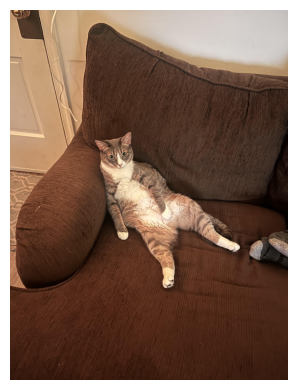

In [10]:
url = 'https://i.redd.it/twpfhcw58xgb1.jpg'
# url = 'https://i.redd.it/aq53vqeaz5nb1.jpg'
# url = 'https://wallup.net/wp-content/uploads/2014/10/cars/Ferrari_Enzo_Sport_Car_HD.jpg'
filepath = keras.utils.get_file(origin=url)
image = keras.utils.load_img(filepath)
image = np.array(image)
h, w, c = image.shape
image_batch = image.reshape((1, h, w, c))
keras_cv.visualization.plot_image_gallery(
  image_batch, rows=1, cols=1, value_range=(0, 255), show=True, scale=4
)

In [11]:
probs = model.predict(image_batch)
probs.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step


(1, 1000)

In [12]:
top_classes = (-probs[0]).argsort()

In [13]:
top_classes[:5]

array([885, 911, 794, 854, 700])

In [14]:
url = 'https://raw.githubusercontent.com/lazyprogrammer/machine_learning_examples/master/kerascv/imagenet_label_names.json'
label_names_filepath = keras.utils.get_file(origin=url)

with open(label_names_filepath) as f:
  label_names = json.load(f)

14193/14193 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step       


In [15]:
label_names

['tench',
 'goldfish',
 'great white shark',
 'tiger shark',
 'hammerhead shark',
 'electric ray',
 'stingray',
 'cock',
 'hen',
 'ostrich',
 'brambling',
 'goldfinch',
 'house finch',
 'junco',
 'indigo bunting',
 'American robin',
 'bulbul',
 'jay',
 'magpie',
 'chickadee',
 'American dipper',
 'kite',
 'bald eagle',
 'vulture',
 'great grey owl',
 'fire salamander',
 'smooth newt',
 'newt',
 'spotted salamander',
 'axolotl',
 'American bullfrog',
 'tree frog',
 'tailed frog',
 'loggerhead sea turtle',
 'leatherback sea turtle',
 'mud turtle',
 'terrapin',
 'box turtle',
 'banded gecko',
 'green iguana',
 'Carolina anole',
 'desert grassland whiptail lizard',
 'agama',
 'frilled-necked lizard',
 'alligator lizard',
 'Gila monster',
 'European green lizard',
 'chameleon',
 'Komodo dragon',
 'Nile crocodile',
 'American alligator',
 'triceratops',
 'worm snake',
 'ring-necked snake',
 'eastern hog-nosed snake',
 'smooth green snake',
 'kingsnake',
 'garter snake',
 'water snake',
 'vin

In [16]:
for c in top_classes[:5]:
  print(label_names[c])

velvet
wool
shower curtain
front curtain
paper towel


![](https://deeplearningcourses.com/notebooks_v3_pxl?sc=7rcMB3xay8d9StlbFLjQsw&n=Pretrained+Classifier)